# Linear Variational Method - Quantum Harmonic Oscillator (QHO)

In this notebook, We will solve using numeric (and symbolic) calculations the Quantum Harmonic Oscillator. We will approximate the energy eigenstates and wavefunctions by using a trial wave function (the variational trial function) that is a linear combination of a basis (specifically, we will use the eigenfunctions of the infinite square well of length L that is symmetric about the origin [-L/2, L/2]). This basis will not be complete since we will cut it and not use the infinite set that will make it complete (because the computer has finite resources).

---

## 1. The Hamiltonian

The Quantum Harmonic Oscillator is defined by its kinetic and potential energy operators:

$$\hat{H} = \hat{T} + \hat{V} = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + \frac{1}{2}m\omega^2 x^2$$

Where $m$ is the mass, $\omega$ is the angular frequency, and $\hbar$ is the reduced Planck's constant. For computational simplicity, we will operate in natural units where $\hbar = m = \omega = 1$.

---

## 2. The Basis Set (Infinite Square Well)

To represent the continuous Hamiltonian operator $\hat{H}$ as a matrix, we must choose a complete set of orthonormal basis functions. We will use the analytical solutions of the 1D Infinite Square Well.

Because our QHO potential is centered at $x=0$, we define our infinite well over a symmetric domain from $-L/2$ to $L/2$. The corresponding normalized basis functions for $n = 1, 2, 3, \dots$ are ([see derivation here](#5.-Analytical-Solution-of-the-Infinite-Square-Well)):


$$\chi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi(x + L/2)}{L}\right)$$

We will artificially truncate this infinite basis to a finite size $N_{basis}$ to perform our numerical calculations.

---

## 3. Proof of the Variational Theorem

The Variational Principle states that the expectation value of the Hamiltonian for any valid trial wavefunction will always be greater than or equal to the true ground state energy $E_0$. 

### 3.1 Proof using resolution of the identity
**Proof:**
We begin by writing the expression for the expected energy of our trial state:

$$E = \frac{\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle}$$

Let $\{|\phi_n\rangle\}$ be the exact, orthonormal eigenstates of the Hamiltonian with exact eigenvalues $E_n$, such that $E_0 \le E_1 \le E_2 \le \dots$

Because these true eigenstates form a complete basis, we can utilize the resolution of the identity (completeness relation):

$$\hat{I} = \sum_{n=0}^{\infty} |\phi_n\rangle\langle\phi_n|$$

We leave the denominator as is, and insert this identity operator between the Hamiltonian and the trial wavefunction in the numerator:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} \langle \psi_{trial} | \hat{H} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

By applying the Hamiltonian operator to its true eigenstate ($\hat{H} | \phi_n \rangle = E_n | \phi_n \rangle$), the expression becomes:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} E_n \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

Since $E_n \ge E_0$ for all states $n$, we can substitute $E_n$ with the ground state energy $E_0$ to establish an inequality:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge \sum_{n=0}^{\infty} E_0 \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

Because $E_0$ is a constant, it factors out of the summation:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0 \sum_{n=0}^{\infty} \langle \psi_{trial} | \phi_n \rangle \langle \phi_n | \psi_{trial} \rangle$$

We can now recognize the resolution of the identity sitting inside the sum, and use it in reverse to collapse the sum back into the inner product of the trial state:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0 \langle \psi_{trial} | \psi_{trial} \rangle$$

Finally, we substitute this inequality back into our original energy equation:

$$E \ge \frac{E_0 \langle \psi_{trial} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle}$$

The inner products in the numerator and denominator perfectly cancel, leaving the final proven inequality:

$$E \ge E_0$$

---

### 3.2 Alternative Proof: expansion using eigenstates

We can also prove the Variational Theorem by explicitly expanding the trial wavefunction as a linear combination of the exact eigenstates. 

Let $\{|\phi_n\rangle\}$ be the exact, orthonormal eigenstates of the Hamiltonian with corresponding exact eigenvalues $E_n$, where $E_0 \le E_1 \le E_2 \le \dots$

We express our arbitrary trial wavefunction $|\psi_{trial}\rangle$ as a linear sum of these true states:

$$|\psi_{trial}\rangle = \sum_{n=0}^{\infty} c_n |\phi_n\rangle$$

Where $c_n$ represents the complex expansion coefficients. 

First, we evaluate the numerator of the energy expectation value, $\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle$:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \left( \sum_{m=0}^{\infty} c_m^* \langle \phi_m | \right) \hat{H} \left( \sum_{n=0}^{\infty} c_n | \phi_n \rangle \right)$$

Applying the Hamiltonian to the right-hand states ($\hat{H} | \phi_n \rangle = E_n | \phi_n \rangle$) yields:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{m=0}^{\infty} \sum_{n=0}^{\infty} c_m^* c_n E_n \langle \phi_m | \phi_n \rangle$$

Because the exact eigenstates are mutually orthonormal ($\langle \phi_m | \phi_n \rangle = \delta_{mn}$), all terms where $m \neq n$ are zero, and the double sum collapses into a single sum:

$$\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} |c_n|^2 E_n$$

Next, we evaluate the denominator, $\langle \psi_{trial} | \psi_{trial} \rangle$, using the same expansion and orthonormality principle:

$$\langle \psi_{trial} | \psi_{trial} \rangle = \sum_{n=0}^{\infty} |c_n|^2$$

Substituting both of these back into our total energy equation gives:

$$E = \frac{\sum_{n=0}^{\infty} |c_n|^2 E_n}{\sum_{n=0}^{\infty} |c_n|^2}$$

Since the true energies are strictly ordered such that $E_n \ge E_0$ for all $n$, replacing $E_n$ with the ground state energy $E_0$ in the numerator establishes a strict inequality:

$$E \ge \frac{\sum_{n=0}^{\infty} |c_n|^2 E_0}{\sum_{n=0}^{\infty} |c_n|^2}$$

Because $E_0$ is a constant, we can pull it entirely outside the summation:

$$E \ge E_0 \frac{\sum_{n=0}^{\infty} |c_n|^2}{\sum_{n=0}^{\infty} |c_n|^2}$$

The summations of the squared coefficients in the numerator and denominator are identical and cancel out perfectly, proving the theorem:

$$E \ge E_0$$

---

## 4. Derivation of the Linear Variational Method (The Secular Equation)

We now apply the Variational Theorem to a specific type of trial function: a linear combination of a finite, chosen basis set. Let $\{|\chi_j\rangle\}$ be a set of $N_{basis}$ basis functions (in our case, the infinite square well states). 

We express our trial wavefunction as:

$$|\psi_{trial}\rangle = \sum_{j=1}^{N_{basis}} c_j |\chi_j\rangle$$

Where $c_j$ are the unknown expansion coefficients. We substitute this expansion into the variational energy expectation value:

$$E = \frac{\langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle}{\langle \psi_{trial} | \psi_{trial} \rangle} = \frac{\sum_{i=1}^{N} \sum_{j=1}^{N} c_i^* c_j \langle \chi_i | \hat{H} | \chi_j \rangle}{\sum_{i=1}^{N} \sum_{j=1}^{N} c_i^* c_j \langle \chi_i | \chi_j \rangle}$$

To simplify the notation, we define two matrix elements:
* **The Hamiltonian Matrix:** $H_{ij} = \langle \chi_i | \hat{H} | \chi_j \rangle$
* **The Overlap Matrix:** $S_{ij} = \langle \chi_i | \chi_j \rangle$

Substituting these into the energy equation yields:

$$E = \frac{\sum_{i,j} c_i^* c_j H_{ij}}{\sum_{i,j} c_i^* c_j S_{ij}}$$

To avoid taking the derivative of a complex fraction using the quotient rule, we rearrange the equation by multiplying the denominator to the left side:

$$E \sum_{i,j} c_i^* c_j S_{ij} = \sum_{i,j} c_i^* c_j H_{ij}$$

According to the Variational Principle, the optimal trial wavefunction is the one that minimizes the energy $E$. We find this minimum by requiring that the variation of the energy with respect to the coefficients is zero. In complex calculus, it is standard practice to treat $c_k$ and its complex conjugate $c_k^*$ as independent variables. Therefore, we take the partial derivative of both sides with respect to a specific coefficient $c_k^*$:

$$\frac{\partial E}{\partial c_k^*} \sum_{i,j} c_i^* c_j S_{ij} + E \sum_{j} c_j S_{kj} = \sum_{j} c_j H_{kj}$$

To find the minimum energy, we enforce the minimization condition: $\frac{\partial E}{\partial c_k^*} = 0$. The first term vanishes entirely, leaving:

$$E \sum_{j} c_j S_{kj} = \sum_{j} c_j H_{kj}$$

We can rearrange this by bringing all terms to one side and factoring out the $c_j$ coefficients:

$$\sum_{j} (H_{kj} - E S_{kj}) c_j = 0$$

This must hold true for all $k = 1, 2, \dots, N_{basis}$. This system of linear equations is known as the **Secular Equation**. Written in compact matrix notation, it becomes the generalized eigenvalue problem:

$$\mathbf{H}\mathbf{c} = E\mathbf{S}\mathbf{c}$$

**Application to our QHO Model:**
Because we have chosen the eigenstates of the infinite square well as our basis, our basis functions are mutually orthonormal. This means the overlap matrix simplifies completely to the identity matrix ($S_{ij} = \delta_{ij}$). Our generalized problem reduces to the standard eigenvalue problem, which we will solve using our Python numerical backend:

$$\mathbf{H}\mathbf{c} = E\mathbf{c}$$

------

> **Historical Note: Why is it called the "Secular" Equation?**
> The term "secular" comes from the Latin word *saeculum*, meaning an age, century, or a very long period of time. In the late 1700s, astronomers like Laplace and Lagrange were studying celestial mechanics, specifically trying to calculate the slow, long-term ("secular") perturbations of planetary orbits—changes that happen over thousands of years, as opposed to short-term periodic changes. 
>
> To find these long-term orbital frequencies, they had to solve a mathematical determinant equation that looked exactly like $|\mathbf{H} - E\mathbf{S}| = 0$. When quantum mechanics was developed a century later and physicists encountered the exact same matrix eigenvalue math, they simply kept the historical astronomy name!

---

## 5. Analytical Solution of the Infinite Square Well

To build our finite basis set, we require the exact analytical solutions to the 1D Infinite Square Well. Because our harmonic oscillator is centered at the origin, we define the boundaries of our infinite well symmetrically at $x = -L/2$ and $x = L/2$. 

The potential energy function is defined as:

$$V(x) = \begin{cases} 0 & -L/2 \le x \le L/2 \\ \infty & \text{otherwise} \end{cases}$$

Inside the well where $V(x) = 0$, the Time-Independent Schrödinger Equation simplifies to:

$$-\frac{\hbar^2}{2m}\frac{d^2\chi}{dx^2} = E\chi$$

We can rewrite this as a standard second-order differential equation:

$$\frac{d^2\chi}{dx^2} + k^2\chi = 0 \quad \text{where} \quad k = \frac{\sqrt{2mE}}{\hbar}$$

To make applying the boundary conditions mathematically simpler, we can introduce a coordinate transformation $u = x + L/2$. This shifts the left wall to $u = 0$ and the right wall to $u = L$. The general solution to the differential equation in this shifted coordinate system is:

$$\chi(u) = A \sin(ku) + B \cos(ku)$$

We now apply the impenetrable boundary conditions. The wavefunction must go to zero at the walls:

1.  **Left Wall (**$u = 0$**):**
    $$\chi(0) = A \sin(0) + B \cos(0) = B = 0$$
    This eliminates the cosine term entirely, leaving $\chi(u) = A \sin(ku)$.

2.  **Right Wall (**$u = L$**):**
    $$\chi(L) = A \sin(kL) = 0$$
    For a non-trivial solution ($A \neq 0$), the argument of the sine function must be an integer multiple of $\pi$:
    $$kL = n\pi \implies k_n = \frac{n\pi}{L} \quad \text{for} \quad n = 1, 2, 3, \dots$$

Substituting our momentum wave vector $k_n$ back into the energy definition $k^2 = 2mE/\hbar^2$ yields the exact energy eigenvalues for the infinite well:

$$E_n = \frac{n^2 \pi^2 \hbar^2}{2mL^2}$$

To find the normalization constant $A$, we require the total probability of finding the particle inside the well to be exactly 1:

$$1 = \int_{-L/2}^{L/2} |\chi_n(x)|^2 dx = A^2 \int_{0}^{L} \sin^2\left(\frac{n\pi u}{L}\right) du$$

Evaluating the integral gives $L/2$, which means:

$$A^2 \left(\frac{L}{2}\right) = 1 \implies A = \sqrt{\frac{2}{L}}$$

Finally, we substitute $A$, $k_n$, and our original coordinate $x = u - L/2$ back into the wavefunction to get the complete, normalized basis functions used in our variational matrix:

$$\chi_n(x) = \sqrt{\frac{2}{L}} \sin\left(\frac{n\pi(x + L/2)}{L}\right)$$

---

## 6. Analytical Solutions of the Quantum Harmonic Oscillator

Before visualizing our numerical results, it is instructive to review the exact analytical solutions of the QHO. We can derive these solutions using two distinct methods: solving the differential equation directly, and using the algebraic method of ladder operators.

### 6.1 Method 1: The Differential Equation Approach

We begin with the Time-Independent Schrödinger Equation (TISE) for the 1D harmonic oscillator:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + \frac{1}{2}m\omega^2 x^2 \psi = E\psi$$

To simplify the math, we introduce a dimensionless coordinate $\xi = \sqrt{\frac{m\omega}{\hbar}}x$ and a dimensionless energy $\epsilon = \frac{2E}{\hbar\omega}$. The TISE simplifies to:

$$\frac{d^2\psi}{d\xi^2} + (\epsilon - \xi^2)\psi = 0$$

**1. The Asymptotic Envelope:**
We first examine the behavior of the wavefunction at extreme distances ($\xi \to \pm\infty$). In this limit, $\xi^2 \gg \epsilon$, so the equation simplifies to $\frac{d^2\psi}{d\xi^2} \approx \xi^2\psi$. The normalizable solution to this asymptotic equation is a Gaussian function, $\psi(\xi) \sim e^{-\xi^2/2}$. 

**2. The Hermite Differential Equation:**
Knowing the asymptotic behavior, we can factor out this Gaussian envelope and express the full wavefunction as the product of the envelope and some unknown function $h(\xi)$:

$$\psi(\xi) = h(\xi)e^{-\xi^2/2}$$

Substituting this guess back into our exact dimensionless TISE and simplifying yields:

$$\frac{d^2h}{d\xi^2} - 2\xi\frac{dh}{d\xi} + (\epsilon - 1)h = 0$$

This is the well-known **Hermite Differential Equation**. For the solutions to remain finite (and thus normalizable), the term $(\epsilon - 1)$ must be an even integer $2n$, where $n = 0, 1, 2, \dots$. This condition strictly quantizes our energy:

$$\epsilon - 1 = 2n \implies \frac{2E}{\hbar\omega} - 1 = 2n \implies E_n = \hbar\omega\left(n + \frac{1}{2}\right)$$

The solutions for $h(\xi)$ are the physicist's Hermite polynomials, $H_n(\xi)$. 

**3. Normalization:**
The full wavefunction is $\psi_n(\xi) = N_n H_n(\xi) e^{-\xi^2/2}$. To find the normalization constant $N_n$, we require the total probability to be 1:

$$\int_{-\infty}^{\infty} |\psi_n(x)|^2 dx = 1$$

Converting $dx$ to $d\xi$ gives $dx = \sqrt{\frac{\hbar}{m\omega}} d\xi$. Using the standard orthogonality integral for Hermite polynomials ($\int_{-\infty}^{\infty} H_n^2(\xi) e^{-\xi^2} d\xi = \sqrt{\pi} 2^n n!$), we solve for the constant:

$$|N_n|^2 \sqrt{\frac{\hbar}{m\omega}} \sqrt{\pi} 2^n n! = 1 \implies N_n = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2^n n!}}$$

Substituting the physical coordinate $\xi = \sqrt{\frac{m\omega}{\hbar}}x$ and our derived normalization constant $N_n$ back into the general solution $\psi_n(\xi) = N_n H_n(\xi) e^{-\xi^2/2}$ gives the final, explicit wavefunctions entirely in terms of the position $x$:

$$\psi_n(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2^n n!}} \exp\left(-\frac{m\omega}{2\hbar}x^2\right) H_n\left(\sqrt{\frac{m\omega}{\hbar}} x\right)$$

For clarity, substituting the first three Hermite polynomials ($H_0(\xi)=1$, $H_1(\xi)=2\xi$, $H_2(\xi)=4\xi^2-2$) gives the explicit forms for the lowest energy states:

* **Ground State ($n=0$):** $$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \exp\left(-\frac{m\omega}{2\hbar}x^2\right)$$

* **First Excited State ($n=1$):** $$\psi_1(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \sqrt{\frac{2m\omega}{\hbar}} x \exp\left(-\frac{m\omega}{2\hbar}x^2\right)$$

* **Second Excited State ($n=2$):** $$\psi_2(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} \frac{1}{\sqrt{2}} \left(2\frac{m\omega}{\hbar}x^2 - 1\right) \exp\left(-\frac{m\omega}{2\hbar}x^2\right)$$

---

### 6.2 Method 2: The Algebraic (Ladder Operator) Approach

A more elegant approach avoids second-order differential equations entirely by factoring the Hamiltonian. We define the annihilation ($\hat{a}$) and creation ($\hat{a}^\dagger$) operators:

$$\hat{a} = \sqrt{\frac{m\omega}{2\hbar}}\left(\hat{x} + \frac{i}{m\omega}\hat{p}\right), \quad \hat{a}^\dagger = \sqrt{\frac{m\omega}{2\hbar}}\left(\hat{x} - \frac{i}{m\omega}\hat{p}\right)$$

Using the fundamental commutation relation $[\hat{x}, \hat{p}] = i\hbar$, we find $[\hat{a}, \hat{a}^\dagger] = 1$. This allows us to rewrite the Hamiltonian entirely in terms of these operators:

$$\hat{H} = \hbar\omega\left(\hat{a}^\dagger\hat{a} + \frac{1}{2}\right)$$

**1. Finding the Ground State:**
The operator $\hat{a}$ lowers the energy of a state by one quanta. Since energy cannot be negative, there must be a lowest ground state $\psi_0$ that is entirely destroyed by the lowering operator: $\hat{a}\psi_0 = 0$. 

Writing $\hat{a}$ in terms of $x$ and the momentum operator $\hat{p} = -i\hbar\frac{d}{dx}$, we get a simple first-order differential equation:

$$\left(\sqrt{\frac{m\omega}{2\hbar}}x + \frac{\hbar}{\sqrt{2m\hbar\omega}}\frac{d}{dx}\right)\psi_0 = 0 \implies \frac{d\psi_0}{dx} = -\frac{m\omega}{\hbar}x \psi_0$$

Integrating this directly yields the exact same Gaussian ground state we found in Method 1:

$$\psi_0(x) = A e^{-\frac{m\omega}{2\hbar}x^2}$$

**2. Building the Excited States:**
With the ground state established, we can generate any excited state simply by repeatedly applying the creation operator. The normalized $n$-th excited state is given by:

$$\psi_n = \frac{1}{\sqrt{n!}}(\hat{a}^\dagger)^n \psi_0$$

> **Computational Note:** In our code, we use natural units ($\hbar = m = \omega = 1$). This simplifies the exact normalized wavefunctions to:
> $$\psi_n(x) = \frac{1}{\sqrt{2^n n! \sqrt{\pi}}} \exp\left(-\frac{x^2}{2}\right) H_n(x)$$



In [1]:
# --- Imports ---

# 1. Jupyter Magic Commands (Forces notebook to reload external .py files)
%load_ext autoreload
%autoreload 2

# 1. Symbolic Mathematics (Analytical Derivations & Units)
import sympy as sp
from IPython.display import display, Math # For rendering LaTeX beautifully in Jupyter

# 2. Numerical Arrays and Matrices
import numpy as np
import math # TODO maybe write this in a different place, doesn't really matter

# 3. Scientific Computing (Integration and Eigenvalue Solvers)
from scipy.integrate import quad
from scipy.linalg import eigh
from scipy.special import eval_hermite

# 4. Visualization (Convergence and Error Graphs)
import matplotlib.pyplot as plt

# 5. Numerical methods (custom implementations)
from numerical_methods import INTEGRATION_DISPATCH
from numerical_methods import EIGEN_PROBLEM_DISPATCH

import config as cfg

In [2]:
# --- Variational Parameters ---
L = 10.0      # The domain size of the infinite well [-L/2, L/2]
N_BASIS = 50  # The size of the basis (k = 1, 2, ..., N_BASIS)
N_STATES = 5  # How many low-lying energy levels to track (should be << N_BASIS for accuracy)

In [3]:
def basis_function(x, n, L) -> float:
    """
    Evaluates the n-th infinite square well basis function at position x.

    Parameters
    ----------
    x : float
        Position where the function is evaluated.
    n : int
        Basis index.
    L : float
        Width of the well.

    Returns
    -------
    float
        Value of the basis function at x.
    """
    normalization = np.sqrt(2.0 / L)
    argument = (n * np.pi * (x + L / 2.0)) / L
    
    return normalization * np.sin(argument)

def exact_qho_wavefunction(x, n, mass=cfg.MASS, omega=cfg.OMEGA, hbar=cfg.HBAR):
    """
    Evaluates the exact analytical QHO wavefunction for state n at position(s) x.
    """
    # 1. The dimensionless coordinate (xi)
    xi = np.sqrt((mass * omega) / hbar) * x
    
    # 2. The Normalization constant (N_n)
    prefactor = (mass * omega / (np.pi * hbar)) ** 0.25
    N_n = prefactor / np.sqrt(float(2**n) * float(math.factorial(n))) # use float to avoid 64-bit integer overflow for large n (n >= 17)
    
    # 3. The Gaussian envelope
    gaussian = np.exp(-(xi**2) / 2.0)
    
    # 4. The Hermite polynomial (Evaluated dynamically via SciPy!)
    hermite = eval_hermite(n, xi)
    
    # 5. Combine them all
    return N_n * gaussian * hermite

def integrand_V(x, n, m, L, mass, omega) -> float:
    """
    The potential energy integrand: chi_n(x) * V(x) * chi_m(x).
    """
    chi_n = basis_function(x, n, L)
    chi_m = basis_function(x, m, L)
    
    V_x = 0.5 * mass * ((omega * x)**2)  # QHO Potential: 1/2 * mass * omega^2 * x^2
    
    return chi_n * V_x * chi_m

## 8. Accelerating the Engine: Analytical Matrix Elements

In our initial numerical experiments, calculating the Hamiltonian matrix was the primary computational bottleneck. For a basis size of $N_{basis} = 50$, the symmetric matrix requires evaluating exactly 1,275 unique potential energy integrals. 

Because the Hamiltonian is a symmetric matrix ($H_{nk} = H_{kn}$), we do not need to calculate all $N^2$ elements. We only need to compute the main diagonal and the upper triangle. The number of unique elements is calculated using the standard formula for a triangular number:
$$\text{Unique Integrals} = \frac{N(N+1)}{2} = \frac{50 \times 51}{2} = 1,275$$

Relying on numerical quadrature (`scipy.integrate.quad`) means evaluating the function at roughly a million distinct grid points every time we build the matrix. To massively accelerate this, we can replace the numerical integration with the exact, closed-form algebraic solution for the potential energy matrix elements ($V_{nk}$). 

*(Note: We use indices $n$ and $k$ here to avoid confusing $i$ with the imaginary unit, and to avoid confusing $m$ with the mass of the particle!)*

The matrix elements are defined by the inner product of the potential operator with our infinite square well basis states:

$$V_{nk} = \langle \chi_n | \hat{V} | \chi_k \rangle = \int_{-L/2}^{L/2} \chi_n(x) \hat{V}(x) \chi_k(x) dx$$

Substituting the harmonic oscillator potential $\hat{V}(x) = \frac{1}{2}m\omega^2 x^2$ and our basis functions, the exact integral becomes:

$$V_{nk} = \frac{m\omega^2}{L} \int_{-L/2}^{L/2} x^2 \sin\left(\frac{n\pi(x + L/2)}{L}\right) \sin\left(\frac{k\pi(x + L/2)}{L}\right) dx$$

Because these integral bounds are symmetric around zero, integrating the shifted arguments of the sine functions directly is algebraically tedious. To make this integral much easier to evaluate analytically using a symbolic mathematics library like SymPy, we apply a coordinate transformation $u = x + L/2$. 

This shifts the integration bounds to $[0, L]$ and changes the $x^2$ term to $(u - L/2)^2$:

$$V_{nk} = \frac{m\omega^2}{L} \int_{0}^{L} \left(u - \frac{L}{2}\right)^2 \sin\left(\frac{n\pi u}{L}\right) \sin\left(\frac{k\pi u}{L}\right) du$$

This integral consists entirely of polynomials multiplied by trigonometric functions, which means it has an exact analytical solution via recursive integration by parts. Instead of solving it by hand, we will use SymPy to evaluate this integral symbolically and generate a fast, compiled Python function to calculate $V_{nk}$ instantly.

In [4]:
# 1. Define Symbolic Variables (Declaring them as real/positive helps SymPy integrate faster)
u, L_sym, mass_sym, omega_sym = sp.symbols('u L m omega', real=True, positive=True)
n_sym, k_sym = sp.symbols('n k', integer=True, positive=True) # quantum numbers

# 2. Define the integrand pieces
prefactor = (mass_sym * omega_sym**2) / L_sym
position_squared = (u - L_sym/2)**2

# 3. Derive the Diagonal Elements (n = k)
print("Deriving Exact Diagonal Elements (n = k)...")
integrand_diag = prefactor * position_squared * sp.sin(n_sym * sp.pi * u / L_sym)**2
V_diag_expr = sp.integrate(integrand_diag, (u, 0, L_sym)).simplify()

# Display the beautiful LaTeX result in the notebook
display(Math(r'V_{nn} = ' + sp.latex(V_diag_expr)))

# 4. Derive the Off-Diagonal Elements (n != k)
print("Deriving Exact Off-Diagonal Elements (n != k)...")
integrand_off = prefactor * position_squared * sp.sin(n_sym * sp.pi * u / L_sym) * sp.sin(k_sym * sp.pi * u / L_sym)
V_off_expr = sp.integrate(integrand_off, (u, 0, L_sym)).simplify()

# Display the beautiful LaTeX result in the notebook
display(Math(r'V_{nk} = ' + sp.latex(V_off_expr)))

# 5. The Magic Step: Compile into ultra-fast numerical functions
calc_V_diag = sp.lambdify((n_sym, L_sym, mass_sym, omega_sym), V_diag_expr, 'numpy')
calc_V_off_diag = sp.lambdify((n_sym, k_sym, L_sym, mass_sym, omega_sym), V_off_expr, 'numpy')

Deriving Exact Diagonal Elements (n = k)...


<IPython.core.display.Math object>

Deriving Exact Off-Diagonal Elements (n != k)...


<IPython.core.display.Math object>

In [5]:
def reconstruct_numerical_wavefunction(x_array, L, N_basis, eigenvector):
    """
    Reconstructs the spatial wavefunction by multiplying the expansion 
    coefficients (eigenvector) by the infinite square well basis functions (transforming to standard basis).
    """
    psi_num = np.zeros_like(x_array)
    
    for i in range(N_basis):
        # Basis function indices start at n=1, but arrays start at i=0
        n = i + 1
        # Add the weighted basis function
        psi_num += eigenvector[i] * basis_function(x_array, n, L)
        
    return psi_num

In [6]:
def build_hamiltonian_matrix(N_BASIS, L, mass, omega, integration_method='trapezoidal', N_GRID=1000):
    """Builds the N_BASIS x N_BASIS Hamiltonian matrix
    
    Parameters
    ----------
    N_BASIS : int
        The size of the basis (k = 1, 2, ..., N_BASIS)
    L : float
        The domain size of the infinite well [-L/2, L/2]
    mass : float
        The mass of the particle
    omega : float
        The angular frequency of the harmonic oscillator
    integration_method : str, optional
        The numerical integration method to use (default is 'trapezoidal')
    N_GRID : int, optional
        The number of grid points for numerical integration (default is 1000)

    Returns
    -------
    np.ndarray
        The N_BASIS x N_BASIS Hamiltonian matrix
    """
    
    H = np.zeros((N_BASIS, N_BASIS))
    
    # Hamiltonian is hermitian, so H_i,j = H_j,i*. We only need to calculate N_BASIS + (N_BASIS - 1) + (N_BASIS - 2) + ... + 1 = N_BASIS * (N_BASIS + 1) / 2 unique elements. The rest can be filled in by symmetry.
    # H = T + V, where T is the kinetic energy term and V is the potential energy term.
    for i in range(N_BASIS):
        for j in range(i, N_BASIS):

            # shift indices to match basis functions (important!)
            n = i + 1
            m = j + 1

            # --- Kinetic Energy (Exact analytical result) ---
            T = 0.0
            # Using T = (hbar^2 * k^2) / 2m
            if n == m:
                k = (n * np.pi) / L
                T = ((cfg.HBAR * k)**2) / (2.0 * mass)

            # --- Potential Energy (Numerical Integration) ---
            V = 0.0

            if integration_method == 'analytical':
                if n == m:
                    V = calc_V_diag(n, L, mass, omega)
                else:
                    V = calc_V_off_diag(n, m, L, mass, omega)

            elif integration_method in INTEGRATION_DISPATCH:
                integration_method_func = INTEGRATION_DISPATCH[integration_method]

                V = integration_method_func(integrand_V, -L/2, L/2, N_GRID, n, m, L, mass, omega)

            else:
                raise ValueError("Invalid integration method selected!")
            
            H[i, j] = T + V
            if i != j:
                H[j, i] = H[i, j]  # Fill in the symmetric element (base functions are real, so H is symmetric)
            
    return H
        
# Maybe calculate S matrix here for generality, but for the infinite square well, the basis functions are orthonormal, so S = I (identity matrix).

def solve_hamiltonian(H, N_STATES, eigen_method):
    """Diagonalizes the Hamiltonian and returns the lowest N_STATES.
    
    Parameters
    ----------
    H : np.ndarray
        The Hamiltonian matrix to diagonalize.
    N_STATES : int
        The number of lowest energy states to return.
    eigen_method : str
        The method to use for eigenvalue decomposition ('scipy', 'QR', 'Jacobi').

    Returns
    -------
    tuple
        A tuple containing:
        - sorted_energies: np.ndarray of the lowest N_STATES eigenvalues (energies).
        - sorted_wavefunctions: np.ndarray of the corresponding eigenvectors (wavefunctions).
    """
    # Solve secular equation, which is just the eigenvalue problem for the Hamiltonian matrix H.
    if eigen_method in EIGEN_PROBLEM_DISPATCH:
        eigen_method_func = EIGEN_PROBLEM_DISPATCH[eigen_method]

        energies, wavefunctions = eigen_method_func(H)
    
    else:
        raise ValueError(f"Invalid eigenvalue method: {eigen_method}")
        
    # Sort eigenvalues from lowest to highest
    sort_indices = np.argsort(energies)
    sorted_energies = energies[sort_indices]
    sorted_wavefunctions = wavefunctions[:, sort_indices]
    
    return sorted_energies[:N_STATES], sorted_wavefunctions[:, :N_STATES]

def calculate_qho_energies_and_states(L_val, N_BASIS_val, N_STATES_val):
    """Master pipeline: Builds the matrix and solves it for given parameters."""
    H_matrix = build_hamiltonian_matrix(
        N_BASIS=N_BASIS_val, 
        L=L_val, 
        mass=cfg.MASS, 
        omega=cfg.OMEGA, 
        integration_method=cfg.integration_method, 
        N_GRID=cfg.N_GRID
    )
    
    energies, states = solve_hamiltonian(
        H=H_matrix, 
        N_STATES=N_STATES_val, 
        eigen_method=cfg.eigenvalue_method
    )
    
    return energies, states

In [7]:
# # The exact theoretical energies (see derivation in the notebook TODO: add markdown derivation and also maybe if possible a link here to the derivation in the notebook)
# exact_energies = np.array([n + 0.5 for n in range(N_STATES)])

# # # the error between the computed energies and the exact energies
# errors = np.abs(energies[:N_STATES] - exact_energies)
# energies

In [8]:
# ==========================================
# SANITY CHECK: Single Run using Defaults
# ==========================================

print(f"Running Sanity Check with L={cfg.DEFAULT_L}, N_BASIS={cfg.DEFAULT_N_BASIS}")

# 1. Run the pipeline
test_energies, test_states = calculate_qho_energies_and_states(
    L_val=cfg.DEFAULT_L, 
    N_BASIS_val=cfg.DEFAULT_N_BASIS, 
    N_STATES_val=cfg.DEFAULT_N_STATES
)

# 2. Calculate the exact theoretical energies (E_n = n + 0.5)
exact_energies = np.array([n + 0.5 for n in range(cfg.DEFAULT_N_STATES)])

# 3. Calculate absolute error
errors = np.abs(test_energies - exact_energies)

# 4. Display Results
print("\nExact Energies:    ", exact_energies)
print("Computed Energies: ", test_energies)
print("Absolute Errors:   ", errors)

Running Sanity Check with L=30.0, N_BASIS=50

Exact Energies:     [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5]
Computed Energies:  [ 0.5         1.5         2.5         3.50000003  4.5000009   5.50000341
  6.50005952  7.50016057  8.50166831  9.50345777 10.52168355 11.53602782
 12.63846846 13.69288731 14.99512947 16.11172441 17.69416648 18.87226775
 20.76354876 21.99114746]
Absolute Errors:    [3.14148707e-12 5.90802962e-11 4.47803883e-09 2.82022570e-08
 8.99302040e-07 3.40679473e-06 5.95214976e-05 1.60567518e-04
 1.66831421e-03 3.45777414e-03 2.16835460e-02 3.60278214e-02
 1.38468464e-01 1.92887306e-01 4.95129468e-01 6.11724411e-01
 1.19416648e+00 1.37226775e+00 2.26354876e+00 2.49114746e+00]


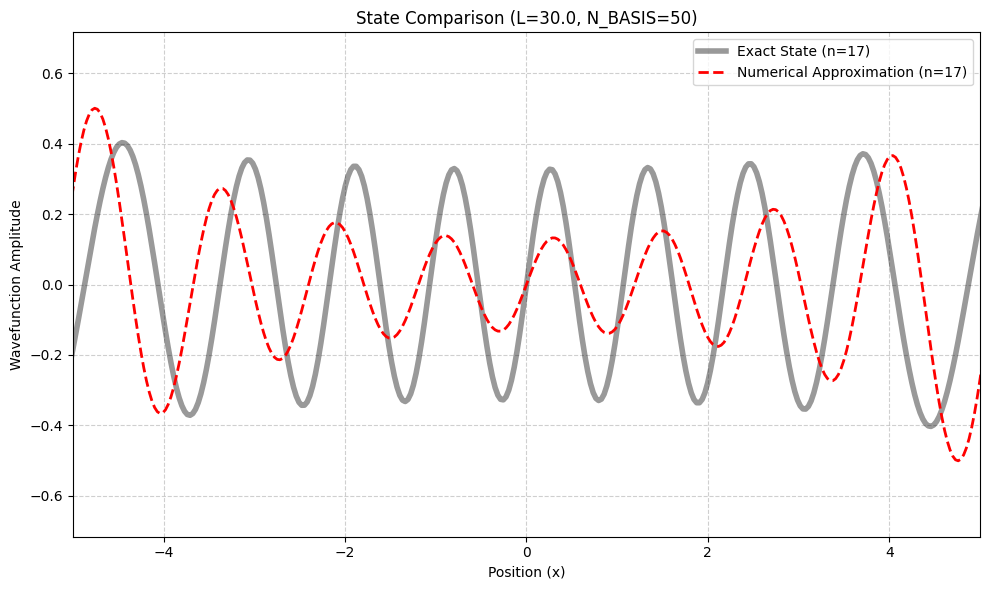

In [15]:
# ==========================================
# SANITY CHECK: Visualizing the nth State
# ==========================================

number = 17  # Index of the state to visualize (0 for ground state)

# 1. Create a high-resolution spatial grid for plotting
x_plot = np.linspace(-cfg.DEFAULT_L/2, cfg.DEFAULT_L/2, 1000)

# 2. Reconstruct the numerical state (Column `number` of test_states)
eigenvector = test_states[:, number]
psi_num_number = reconstruct_numerical_wavefunction(
    x_array=x_plot, 
    L=cfg.DEFAULT_L, 
    N_basis=cfg.DEFAULT_N_BASIS, 
    eigenvector=eigenvector
)

# 3. Calculate the exact state (n=`number`)
psi_exact_number = exact_qho_wavefunction(x=x_plot, n=number)

# 4. Handle Arbitrary Phase (Flip numerical state if it points the wrong way)
if np.sum(psi_num_number * psi_exact_number) < 0:
    psi_num_number *= -1

# 5. Plot the comparison
plt.figure(figsize=(10, 6))

# The exact universe (Thick, semi-transparent solid line)
plt.plot(x_plot, psi_exact_number, 'k-', linewidth=4, alpha=0.4, label=f'Exact State (n={number})')

# Your numerical approximation (Dashed colored line)
plt.plot(x_plot, psi_num_number, 'r--', linewidth=2, label=f'Numerical Approximation (n={number})')

plt.title(f"State Comparison (L={cfg.DEFAULT_L}, N_BASIS={cfg.DEFAULT_N_BASIS})")
plt.xlabel("Position (x)")
plt.ylabel("Wavefunction Amplitude")

# Zoom in on the center of the well where the QHO wave lives
plt.xlim(-5, 5) 

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
# # ==========================================
# # EXPERIMENT 1: Error vs. N_BASIS (Fixed L)
# # ==========================================

# # Experimental Setup
# L_fixed = 30.0
# basis_sizes = np.arange(20, 70, 1) # Test N_BASIS from 20 to 70 in steps of 1
# tracked_states = 20                # Track the first 20 states for a clean graph

# exact_energies = np.array([n + 0.5 for n in range(tracked_states)])
# errors_vs_N = []

# print(f"Sweeping N_BASIS from 20 to 40 with fixed L={L_fixed}...")

# for N in basis_sizes:
#     # We pass the experimental N directly into your math engine
#     calc_energies, _ = calculate_qho_energies_and_states(
#         L_val=L_fixed, 
#         N_BASIS_val=N, 
#         N_STATES_val=tracked_states
#     )
    
#     # Calculate the absolute error against the theoretical formula
#     error = np.abs(calc_energies - exact_energies)
#     errors_vs_N.append(error)

# # Convert list to a 2D NumPy array for easy plotting slicing
# errors_vs_N = np.array(errors_vs_N)

# # --- Matplotlib Plotting ---
# plt.figure(figsize=(10, 6))
# for state in range(tracked_states):
#     # Using a logarithmic y-axis to see the exponential convergence
#     plt.semilogy(basis_sizes, errors_vs_N[:, state], marker='o', label=f'State n={state}')

# plt.title(f'Convergence Error vs. Basis Size (Fixed L = {L_fixed})')
# plt.xlabel('Number of Basis Functions (N_BASIS)')
# plt.ylabel('Absolute Error (Log Scale)')
# plt.legend()
# plt.grid(True, which="both", ls="--", alpha=0.6)
# plt.show()

In [11]:
# calc_energies

In [12]:
# errors

In [13]:
# # ==========================================
# # EXPERIMENT 2: Error vs. Box Size L (Fixed N_BASIS)
# # ==========================================

# # Experimental Setup
# N_fixed = 100  # Using the optimal basis size from your previous graphs
# L_values = np.arange(25, 50, 1) # Test L from 25 to 50 in steps of 1
# tracked_states = 20

# exact_energies = np.array([n + 0.5 for n in range(tracked_states)])
# errors_vs_L = []

# print(f"Sweeping L from 25 to 50 with fixed N_BASIS={N_fixed}...")

# for L_val in L_values:
#     # Pass the experimental L directly into your math engine
#     calc_energies, _ = calculate_qho_energies_and_states(
#         L_val=L_val, 
#         N_BASIS_val=N_fixed, 
#         N_STATES_val=tracked_states
#     )
#     error = np.abs(calc_energies - exact_energies)
#     errors_vs_L.append(error)

# errors_vs_L = np.array(errors_vs_L)

# # --- Matplotlib Plotting ---
# plt.figure(figsize=(10, 6))

# # Plotting a subset of the 20 states to keep the graph readable
# states_to_plot = [i for i in range(tracked_states)]

# for state in states_to_plot:
#     plt.semilogy(L_values, errors_vs_L[:, state], marker='s', label=f'State n={state}')

# plt.title(f'Convergence Error vs. Box Size (Fixed N_BASIS = {N_fixed})')
# plt.xlabel('Size of the Infinite Well (L)')
# plt.ylabel('Absolute Error (Log Scale)')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.grid(True, which="both", ls="--", alpha=0.6)
# plt.tight_layout()
# plt.show()